# Experimento con VGG19 – Visión por Computadora II

Notebook separado para probar la performance de VGG19.

## Integrantes

- Acevedo Zain, Gaspar (acevedo.zain.gaspar@gmail.com)
- Lauro, Rodrigo (ing.rodrigo.lauro@gmail.com)
- Rodrigues da Cruz, Nicolás (Nicolasrdc151@gmail.com)

## Descripción del problema

- Tipo de problema: Clasificación
- Descripción: Detección de nódulos pulmonares en tomografías de tórax.
- Detalles: Desarrollar un modelo de aprendizaje profundo que identifique la presencia de nódulos pulmonares en imágenes de tomografía computarizada (CT) de tórax.​
- Dataset: [Chest CT-Scan images Dataset](https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images)

## Imports

In [95]:
import os
from zipfile import ZipFile

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import vgg19, VGG19_Weights

from torchmetrics.functional import recall as recall_fn

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


## Descarga del dataset

In [96]:
!curl -L -o "/content/dataset.zip" "https://www.kaggle.com/api/v1/datasets/download/mohamedhanyyy/chest-ctscan-images"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  118M  100  118M    0     0   119M      0 --:--:-- --:--:-- --:--:--  161M


In [97]:
zip_file = "/content/dataset.zip"
dataset_unzip_folder = "/content/."
dataset_folder = "/content/Data"
DATASET_TRAIN = os.path.join(dataset_folder, "train")
DATASET_TEST = os.path.join(dataset_folder, "test")
DATASET_VALID = os.path.join(dataset_folder, "valid")

In [98]:
# Descomprimo si NO existe la carpeta /content/dataset_emociones
if not os.path.isdir(dataset_folder):
  with ZipFile(zip_file, 'r') as zip_object:
    zip_object.extractall(path=dataset_unzip_folder)

In [99]:
DATASET_TRAIN = os.path.join(dataset_folder, "train")
DATASET_TEST  = os.path.join(dataset_folder, "test")
DATASET_VALID = os.path.join(dataset_folder, "valid")

print("Train path:", DATASET_TRAIN)
print("Test path:", DATASET_TEST)
print("Valid path:", DATASET_VALID)

Train path: /content/Data/train
Test path: /content/Data/test
Valid path: /content/Data/valid


In [100]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)  # entrada típica para VGG19

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

val_test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=train_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=val_test_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=val_test_transform)

NUM_CLASSES = len(train_data.classes)
print("Clases:", train_data.classes)
print("NUM_CLASSES:", NUM_CLASSES)

train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(dataset=validation_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)

for x, y in train_loader:
    print("Batch shape:", x.shape)  # [batch, 3, 224, 224]
    break

Clases: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
NUM_CLASSES: 4
Batch shape: torch.Size([32, 3, 224, 224])


In [101]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

EPOCHS = 5            # podés cambiarlo
LEARNING_RATE = 1e-4  # para el classifier

Device: cpu


In [102]:
weights = VGG19_Weights.IMAGENET1K_V1
vgg19_model = vgg19(weights=weights)

# congelar features convolucionales
for param in vgg19_model.features.parameters():
    param.requires_grad = False

# reemplazar la última capa fully-connected
in_features = vgg19_model.classifier[6].in_features
vgg19_model.classifier[6] = nn.Linear(in_features, NUM_CLASSES)

vgg19_model = vgg19_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg19_model.classifier.parameters(), lr=LEARNING_RATE)

vgg19_model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [103]:
def train_one_epoch(model, loader, optimizer, criterion, device, num_classes):
    model.train()
    running_loss = 0.0
    all_outputs = []
    all_targets = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        all_outputs.append(outputs.detach())
        all_targets.append(labels.detach())

    epoch_loss = running_loss / len(loader)
    outputs_cat = torch.cat(all_outputs)
    targets_cat = torch.cat(all_targets)

    epoch_recall = recall_fn(
        outputs_cat,
        targets_cat,
        task="multiclass",
        num_classes=num_classes,
        average="macro"
    ).item()

    return epoch_loss, epoch_recall


def eval_one_epoch(model, loader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    all_outputs = []
    all_targets = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            all_outputs.append(outputs)
            all_targets.append(labels)

    epoch_loss = running_loss / len(loader)
    outputs_cat = torch.cat(all_outputs)
    targets_cat = torch.cat(all_targets)

    epoch_recall = recall_fn(
        outputs_cat,
        targets_cat,
        task="multiclass",
        num_classes=num_classes,
        average="macro"
    ).item()

    return epoch_loss, epoch_recall, outputs_cat, targets_cat


In [104]:
history = {
    "train_loss": [],
    "valid_loss": [],
    "train_recall": [],
    "valid_recall": []
}

best_val_loss = float("inf")
best_state_dict = None

for epoch in range(EPOCHS):
    train_loss, train_recall = train_one_epoch(
        vgg19_model, train_loader, optimizer, criterion, device, NUM_CLASSES
    )

    valid_loss, valid_recall, _, _ = eval_one_epoch(
        vgg19_model, validation_loader, criterion, device, NUM_CLASSES
    )

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["train_recall"].append(train_recall)
    history["valid_recall"].append(valid_recall)

    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        best_state_dict = vgg19_model.state_dict()

    print(
        f"Época {epoch+1}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} - Train recall: {train_recall:.4f} | "
        f"Valid loss: {valid_loss:.4f} - Valid recall: {valid_recall:.4f}"
    )

if best_state_dict is not None:
    vgg19_model.load_state_dict(best_state_dict)


Época 1/5 | Train loss: 1.0954 - Train recall: 0.4880 | Valid loss: 0.9515 - Valid recall: 0.5757
Época 2/5 | Train loss: 0.7421 - Train recall: 0.6671 | Valid loss: 0.7519 - Valid recall: 0.6650
Época 3/5 | Train loss: 0.5789 - Train recall: 0.7536 | Valid loss: 0.7153 - Valid recall: 0.7830
Época 4/5 | Train loss: 0.4166 - Train recall: 0.8281 | Valid loss: 0.6438 - Valid recall: 0.7197
Época 5/5 | Train loss: 0.3434 - Train recall: 0.8733 | Valid loss: 0.6650 - Valid recall: 0.7647


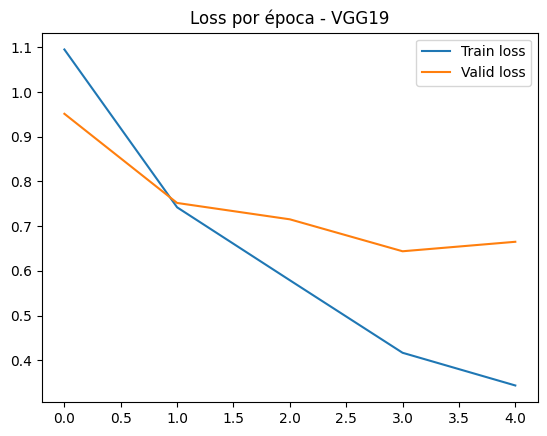

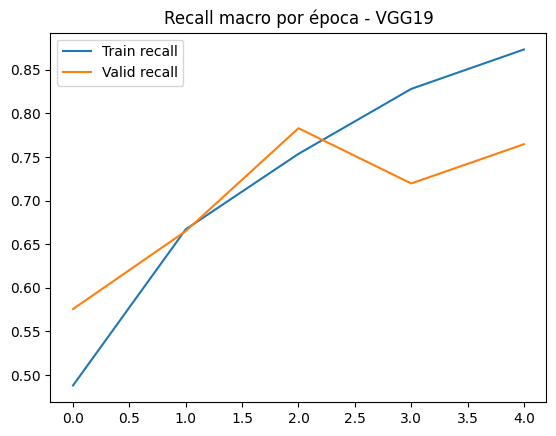

In [105]:
plt.figure()
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["valid_loss"], label="Valid loss")
plt.title("Loss por época - VGG19")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_recall"], label="Train recall")
plt.plot(history["valid_recall"], label="Valid recall")
plt.title("Recall macro por época - VGG19")
plt.legend()
plt.show()


Test loss:   0.6061
Test recall: 0.7312
Classification report (VGG19 - Test):
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.64      0.72      0.68       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.64      0.53      0.58        51
                                          normal       1.00      0.98      0.99        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.74      0.69      0.71        90

                                        accuracy                           0.73       315
                                       macro avg       0.76      0.73      0.74       315
                                    weighted avg       0.73      0.73      0.73       315



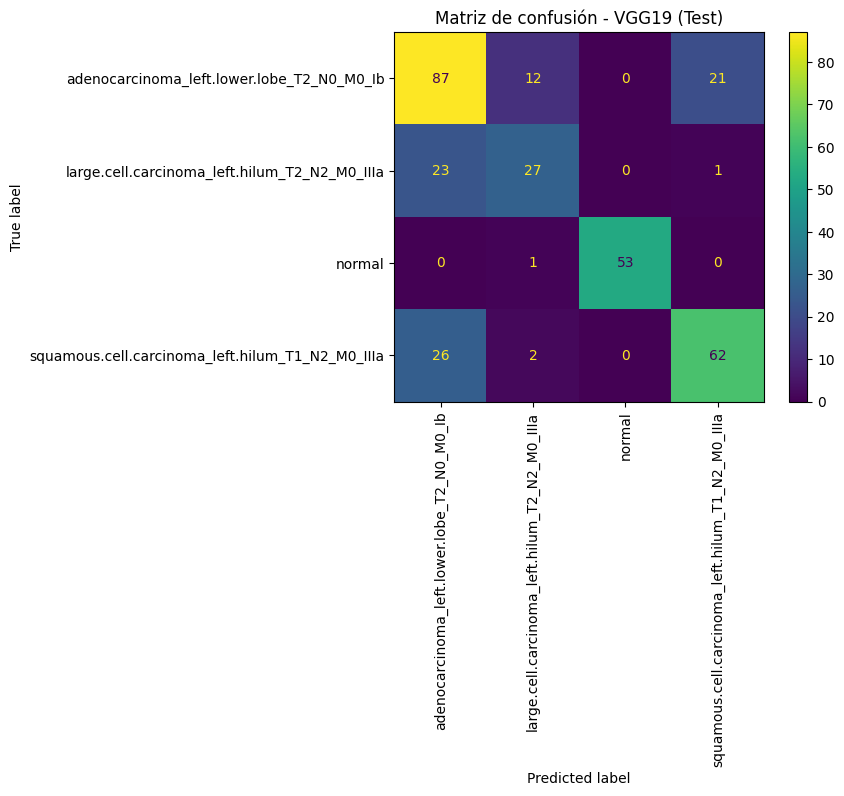

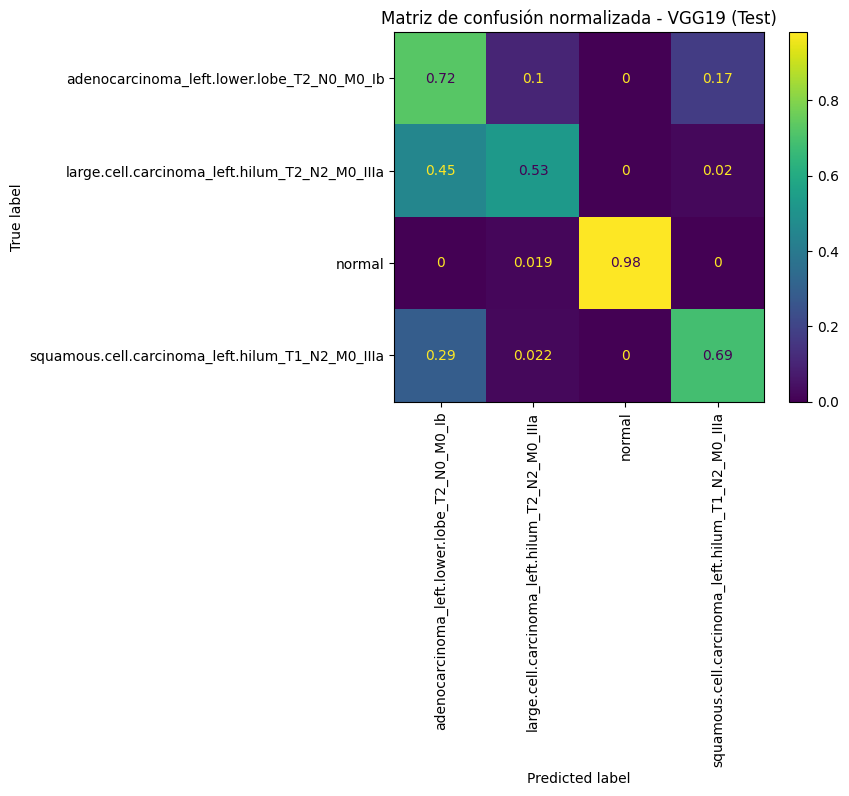

In [106]:
test_loss, test_recall, test_outputs, test_targets = eval_one_epoch(
    vgg19_model, test_loader, criterion, device, NUM_CLASSES
)

print(f"Test loss:   {test_loss:.4f}")
print(f"Test recall: {test_recall:.4f}")

y_true = test_targets.cpu().numpy()
y_pred = test_outputs.argmax(dim=1).cpu().numpy()

print("Classification report (VGG19 - Test):")
print(classification_report(y_true, y_pred, target_names=train_data.classes))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.classes)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.title("Matriz de confusión - VGG19 (Test)")
plt.show()

cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=train_data.classes)
disp_norm.plot()
disp_norm.ax_.tick_params(axis='x', rotation=90)
plt.title("Matriz de confusión normalizada - VGG19 (Test)")
plt.show()
